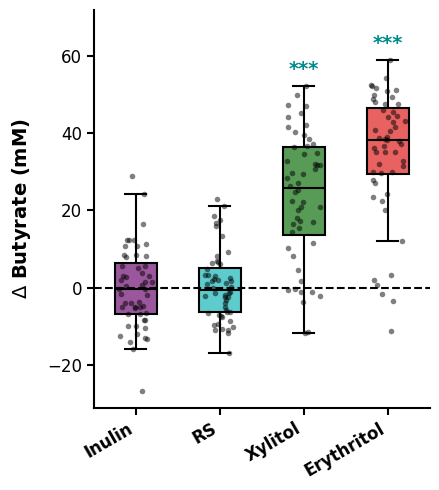

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mc
from scipy import stats
import statsmodels.stats.multitest as multitest
import warnings

warnings.filterwarnings('ignore')

# =============================================================================
# 1. Settings & Color Blending
# =============================================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
DPI_SETTING = 600

def clean_and_convert(vals):
    s_vals = pd.Series(vals).astype(str).str.strip()
    s_vals = s_vals.replace(['Undetermined', '-', 'nan', 'NaN', '#VALUE!', ''], '0')
    return pd.to_numeric(s_vals, errors='coerce').fillna(0)

def lighten_hex(hex_color, factor=0.3):
    """指定された16進数の色を、係数(0.0〜1.0)の割合だけ白に近づける（明度を上げる）"""
    r, g, b = mc.to_rgb(hex_color)
    r = r + (1 - r) * factor
    g = g + (1 - g) * factor
    b = b + (1 - b) * factor
    return mc.to_hex((r, g, b))

# Original base colors extracted strictly from previous prompt (@4cd.ipynb)
base_colors = {
    'Inulin': '#800080',       # Purple
    'RS': '#00CED1',           # Turquoise
    'Xylitol': '#008000',      # Green
    'Erythritol': '#FF0000'    # Red
}

# Apply 30% lightening to make them slightly softer as requested
palette_dict = {k: lighten_hex(v, 0.3) for k, v in base_colors.items()}

target_ingredients = ['Inulin', 'Resistant starch', 'Xylitol', 'Erythritol']
name_map = {
    'Inulin': 'Inulin',
    'Resistant starch': 'RS',
    'Xylitol': 'Xylitol',
    'Erythritol': 'Erythritol'
}
order = ['Inulin', 'RS', 'Xylitol', 'Erythritol']

# =============================================================================
# 2. Data Loading & Correlation (FDR Correction for substrates)
# =============================================================================
df_but = pd.read_csv('Butyrate(mM).csv')
donor_cols = [c for c in df_but.columns if c.startswith('HS-')]

# Control
ctrl_vals = clean_and_convert(df_but[df_but['KULFFI'].str.strip() == 'Control'][donor_cols].iloc[0]).values

plot_data = []
p_values = []
valid_targets = []

for ing in target_ingredients:
    row = df_but[df_but['KULFFI'].str.strip() == ing]
    if len(row) == 0: continue

    treat_vals = clean_and_convert(row[donor_cols].iloc[0]).values
    delta = treat_vals - ctrl_vals

    # Statistics: Substrate vs Control (Wilcoxon signed-rank)
    if np.all(delta == 0):
        p = 1.0
    else:
        try:
            stat, p = stats.wilcoxon(treat_vals, ctrl_vals)
        except ValueError:
            p = 1.0

    p_values.append(p)
    valid_targets.append(name_map[ing])

    for d in delta:
        plot_data.append({'Substrate': name_map[ing], 'Delta_Butyrate': d})

# FDR Correction
_, q_values, _, _ = multitest.multipletests(p_values, alpha=0.05, method='fdr_bh')
q_dict = dict(zip(valid_targets, q_values))

df_plot = pd.DataFrame(plot_data)
df_plot['Substrate'] = pd.Categorical(df_plot['Substrate'], categories=order, ordered=True)

# =============================================================================
# 3. Figure Generation
# =============================================================================
fig, ax = plt.subplots(figsize=(4.5, 5))

palette = [palette_dict[x] for x in order]

sns.boxplot(x='Substrate', y='Delta_Butyrate', data=df_plot, order=order, palette=palette,
            width=0.5, showfliers=False, ax=ax)

for patch in ax.patches:
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)
for line in ax.lines:
    line.set_color('black')
    line.set_linewidth(1.5)

sns.stripplot(x='Substrate', y='Delta_Butyrate', data=df_plot, order=order,
              color='black', alpha=0.5, size=4, jitter=0.2, ax=ax)

ax.axhline(0, color='black', linestyle='--', linewidth=1.5)

ax.set_ylabel(r'$\Delta$ Butyrate (mM)', fontsize=14, fontweight='bold', labelpad=10)
ax.set_xlabel('')

ax.tick_params(axis='both', labelsize=12, width=1.5, length=5)
ax.set_xticklabels(ax.get_xticklabels(), fontweight='bold', fontsize=12, rotation=30, ha='right')

for s in ['top', 'right']: ax.spines[s].set_visible(False)
for s in ['left', 'bottom']: ax.spines[s].set_linewidth(1.5)

def get_star(q):
    if q < 0.001: return '***'
    elif q < 0.01: return '**'
    elif q < 0.05: return '*'
    else: return ''

y_max = df_plot['Delta_Butyrate'].max()
y_range = y_max - df_plot['Delta_Butyrate'].min()
ax.set_ylim(df_plot['Delta_Butyrate'].min() - y_range*0.05, y_max + y_range*0.15)

for i, sub in enumerate(order):
    star_text = get_star(q_dict[sub])
    if star_text:
        g_max = df_plot[df_plot['Substrate'] == sub]['Delta_Butyrate'].max()
        # Changed star color to match the Dark Cyan (#008B8B) established in Figure 4
        ax.text(i, g_max + y_range*0.02, star_text,
                ha='center', va='bottom', fontsize=14, fontweight='bold', color='#008B8B')

plt.tight_layout()

# =============================================================================
# 4. Output
# =============================================================================
plt.savefig('Figure_5a.pdf', dpi=DPI_SETTING, bbox_inches='tight', transparent=True)